In [1]:
library(Seurat)
library(dplyr)
library(ggplot2)
library(org.Hs.eg.db)
library(msigdbr)
library(enrichplot)
library(clusterProfiler)
library(stringr)
library(ggpubr)
library(tidyr)

The legacy packages maptools, rgdal, and rgeos, underpinning the sp package,
which was just loaded, will retire in October 2023.
Please refer to R-spatial evolution reports for details, especially
https://r-spatial.org/r/2023/05/15/evolution4.html.
It may be desirable to make the sf package available;
package maintainers should consider adding sf to Suggests:.
The sp package is now running under evolution status 2
     (status 2 uses the sf package in place of rgdal)

Attaching SeuratObject


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Loading required package: AnnotationDbi

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: 'BiocGenerics'


The following objects are masked from 'package:dplyr':

    combine, intersect, setdiff, union


The following objects are masked from 'package:stats'

In [62]:
BBID <- read.table("/opt/data/private/CD8_IAV.vs.HC_DAVID_BBID.txt",header = TRUE,sep = '\t',quote = '')
BIOCARTA <- read.table("/opt/data/private/CD8_IAV.vs.HC_DAVID_BIOCARTA.txt",header = TRUE,sep = '\t',quote = '')
KEGG <- read.table("/opt/data/private/CD8_IAV.vs.HC_DAVID_KEGG.txt",header = TRUE,sep = '\t',quote = '')
REACTOME <- read.table("/opt/data/private/CD8_IAV.vs.HC_DAVID_REACTOME.txt",header = TRUE,sep = '\t',quote = '')
GO_BP <- read.table("/opt/data/private/CD8_IAV.vs.HC_DAVID_GO_BP.txt",header = TRUE,sep = '\t',quote = '')

In [63]:
KEGG$Category <- "KEGG"
REACTOME$Category <- "REACTOME"
GO_BP$Category <- "GO_BP"

BBID$Term <- str_remove(BBID$Term, ".*\\.")
BIOCARTA$Term <- str_remove(BIOCARTA$Term, ".*:")
KEGG$Term <- str_remove(KEGG$Term, ".*:")
REACTOME$Term <- str_remove(REACTOME$Term, ".*~")
GO_BP$Term <- str_remove(GO_BP$Term, ".*~")

KEGG <- KEGG[c(14,24,28,31),]
BIOCARTA <- BIOCARTA[c(5),]
REACTOME <- REACTOME[c(3),]
GO_BP <- GO_BP[c(36,26,37),]

all = rbind(GO_BP,BBID,BIOCARTA,KEGG,REACTOME)

colnames(all)[colnames(all) == "X."] <- "GeneRatio"
all$GeneRatio <- as.numeric(all$GeneRatio)
all$GeneRatio <- round(all$GeneRatio / 100, 3)

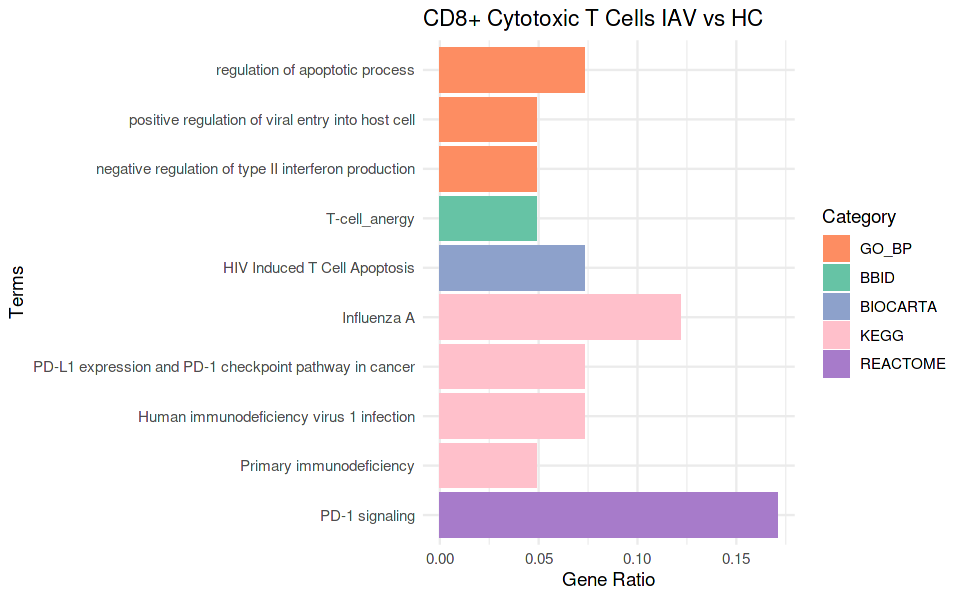

In [64]:
colors <- c("#FD8D62","#66C3A5","#8DA1CB","#FFC0CB","#A77BCA")

all$Term <- factor(all$Term, levels = rev(unique(all$Term)))

options(repr.plot.width = 8, repr.plot.height = 5)
p1 <- ggplot(data = all, aes(x = Term, y = GeneRatio, fill = Category)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = colors,
                    breaks = c("GO_BP", "BBID", "BIOCARTA", "KEGG", "REACTOME")) +
  coord_flip() + 
  labs(title = "CD8+ Cytotoxic T Cells IAV vs HC",
       x = "Terms",
       y = "Gene Ratio")  +
  theme_minimal()
p1

In [65]:
IAV.vs.COVID$gene <- rownames(IAV.vs.COVID)

In [66]:
IAV.vs.COVID <- IAV.vs.COVID %>% filter(avg_log2FC > 0)
IAV.vs.COVID <- IAV.vs.COVID$gene

In [67]:
markers.gene_symbol <- as.character(IAV.vs.COVID)
markers.entrez_id <- mapIds(x = org.Hs.eg.db,
                            keys = markers.gene_symbol,
                            keytype = "SYMBOL",
                            column = "ENTREZID")
markers.entrez_id <- na.omit(markers.entrez_id)

'select()' returned 1:1 mapping between keys and columns



In [68]:
erich.kegg.Treg <- enrichKEGG(gene = markers.entrez_id,
                              organism = "hsa",
                              keyType = "kegg",
                              pAdjustMethod = "BH",
                              pvalueCutoff = 5,
                              qvalueCutoff = 5)

--> No gene can be mapped....

--> Expected input gene ID: 

--> return NULL...



In [69]:
erich.kegg.markers <- readRDS("/opt/data/private/CD8_IAV.vs.COVID.enrich.kegg.rds")

In [70]:
result_df <- as.data.frame(erich.kegg.markers)
result_df$GeneRatio <- as.character(result_df$GeneRatio)
result_df$GeneRatio <- sapply(result_df$GeneRatio, function(x) {
  if (!is.na(x) && grepl("/", x)) {
    parts <- as.numeric(unlist(strsplit(x, "/")))
    return(parts[1] / parts[2]) 
  } else {
    return(NA)
  }
})
result_df$GeneRatio <- result_df$GeneRatio

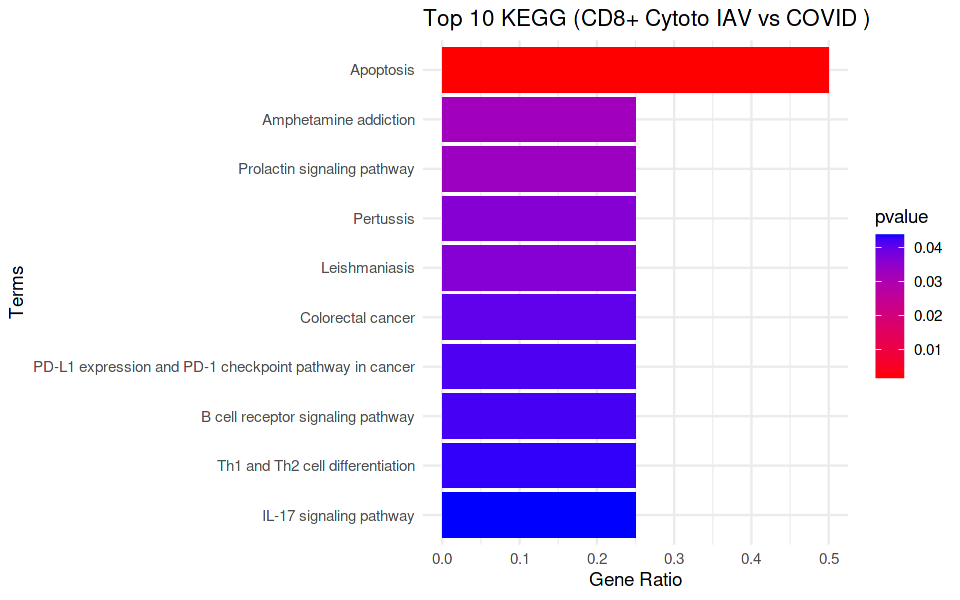

In [71]:
top_results <- result_df[order(result_df$pvalue), ][1:10, ]

options(repr.plot.width = 8, repr.plot.height = 5)
p2 <- ggplot(top_results, aes(x = reorder(Description, -pvalue), y = GeneRatio, fill = pvalue)) + 
  geom_bar(stat = "identity") +
  coord_flip() +  
  scale_fill_gradient(low = "red", high = "blue") + 
  labs(title = "Top 10 KEGG (CD8+ Cytoto IAV vs COVID )",
       x = "Terms",
       y = "Gene Ratio") +
  theme_minimal()
p2